# 演示工具和LLM的交互方式

## 新知识点
- tools_condition：langraph预置的条件边函数，固定返回['tools',END]
- ToolMessage/HumanMessage/AIMessage/SystemMessage： langchain预置的消息类型
- ToolNode：langgraph预置函数，tool函数只需要关注计算过程，由ToolNode来决策函数的调用以及message的包装

## 要求
- 必须使用langchain的消息类型进行交互
- 必须使用tools_condition条件边函数
- llm节点作为router，需要能够决策走tools分支还是END

### 实现步骤
- 创建llm client并绑定工具
- 创建router节点/tools节点
- 创建并编译图，打印其结构
- 测试图

In [1]:

# 通用步骤
from langchain_openai import ChatOpenAI


glm_client = ChatOpenAI(
    api_key="d1de7475090740ebb6c887167a6a8b98.2WUSfYbmgQwYLKF4",
    base_url="https://open.bigmodel.cn/api/paas/v4/",
    model="glm-4.7",
)

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
# 绑定工具
from langchain.messages import ToolMessage


# 工具函数
def multipy(a: int, b: int) -> int:
    """计算 a 和 b 的乘积"""
    return a * b

glm_client_with_tool = glm_client.bind_tools([multipy])

In [3]:
# 创建router节点
from langgraph.graph import MessagesState


def router_node(state: MessagesState):
    return {"messages": [glm_client_with_tool.invoke(state["messages"])]}

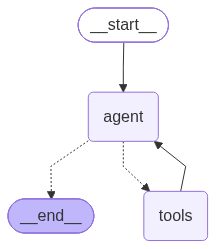

In [ ]:
# 创建图
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition


graph = StateGraph(MessagesState)
graph.add_node("agent",router_node)
graph.add_node("tools", ToolNode([multipy]))

graph.add_edge(START, "agent")
graph.add_conditional_edges("agent", tools_condition)
graph.add_edge("tools","agent") # tools可以直接END，也可以回到agent实现循环，在多个tool的场景下循环比较常见

app = graph.compile()

from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [19]:
from langchain.messages import HumanMessage


res = app.invoke({"messages":[HumanMessage(content="5乘以18 等于多少？")]})

In [21]:
for msg in res["messages"]:
    msg.pretty_print()
    # print(msg.model_dump_json(indent=2))

================================ Human Message =================================

5乘以18 等于多少？
================================== Ai Message ==================================

我来帮您计算5乘以18的结果。
Tool Calls:
  multipy (call_-7347688831472101405)
 Call ID: call_-7347688831472101405
  Args:
    a: 5
    b: 18
================================= Tool Message =================================
Name: multipy

90
================================== Ai Message ==================================

5乘以18等于90。


In [17]:
res = app.invoke({"messages":[HumanMessage(content='你好，介绍下langchain？')]})
for msg in res["messages"]:
    # print(msg.model_dump_json(indent = 2))
    msg.pretty_print()

================================ Human Message =================================

你好，介绍下langchain？
================================== Ai Message ==================================

你好！我来为你介绍一下LangChain。

## LangChain 是什么？

LangChain 是一个开源框架，专门用于开发基于大语言模型（LLM）的应用程序。它由 Harrison Chase 创建，现已成为构建 LLM 应用的热门工具之一。

## 核心功能

### 1. **模型集成**
- 支持多种大语言模型（GPT、Claude、Llama等）
- 统一的API接口，便于切换不同模型
- 支持文本生成、对话、嵌入等不同模型类型

### 2. **提示词管理**
- 提示词模板系统
- 提示词优化和管理
- 动态提示词生成

### 3. **记忆机制**
- 对话历史管理
- 长短期记忆存储
- 会话状态维护

### 4. **链式调用**
- 将多个组件连接成处理流程
- 复杂任务分解和执行
- 条件分支和循环控制

### 5. **智能体（Agents）**
- 自主决策能力
- 工具调用和外部API集成
- 任务规划和执行

### 6. **数据连接**
- 文档加载和处理
- 向量数据库集成
- RAG（检索增强生成）支持

## 主要应用场景

- **聊天机器人**：构建智能对话系统
- **文档问答**：基于文档内容的智能问答
- **代码助手**：编程辅助和代码生成
- **数据分析**：自然语言数据处理
- **工作流自动化**：智能任务编排

## 优势

1. **模块化设计**：组件可独立使用或组合
2. **易于扩展**：支持自定义组件
3. **社区活跃**：丰富的插件和集成
4. **生产就绪**：适合商业应用部署

## 技术栈

- Python 和 JavaScript/TypeScript 支持
- 与主流云服务集成
- 支持本地和云端部署

LangChain 正在快速发展和迭代，是当前构建 AI 应用的核心工具之一。你对哪个方面特别感兴趣吗？